In [8]:
import pandas as pd

data = {'luas' : [6, 8, 10, 14, 18],
        'harga' : [7, 9, 13, 17.5, 18]}

df = pd.DataFrame(data)
df

,luas,harga
0,6,7.0
1,8,9.0
2,10,13.0
3,14,17.5
4,18,18.0


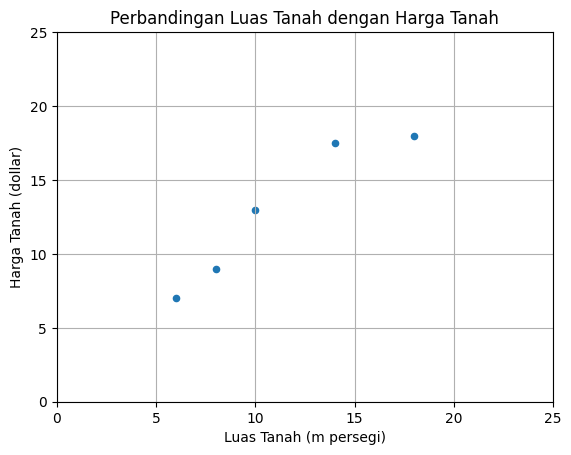

In [9]:
import matplotlib.pyplot as plt

df.plot(kind='scatter', x='luas', y='harga')
plt.title('Perbandingan Luas Tanah dengan Harga Tanah')
plt.xlabel('Luas Tanah (m persegi)')
plt.ylabel('Harga Tanah (dollar)')
plt.xlim(0,25)
plt.ylim(0,25)
plt.grid(True)
plt.show()

In [10]:
import numpy as np

X = np.array(df['luas']).reshape(-1, 1)   # harus 2D
y = np.array(df['harga'])

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print(f'Intercept: {model.intercept_}')
print(f'Slope: {model.coef_[0]}')

Intercept: 1.965517241379315
Slope: 0.9762931034482755


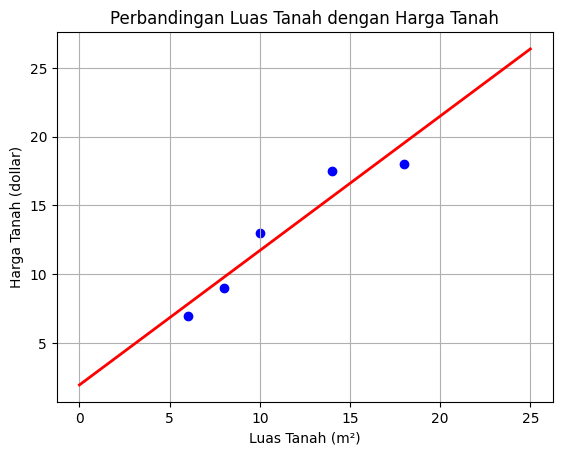

In [5]:
X_vis = np.array([0, 25]).reshape(-1, 1)
y_vis = model.predict(X_vis)

plt.scatter(X, y, color='blue')
plt.plot(X_vis, y_vis, color='red', linewidth=2)
plt.title('Perbandingan Luas Tanah dengan Harga Tanah')
plt.xlabel('Luas Tanah (m²)')
plt.ylabel('Harga Tanah (dollar)')
plt.grid(True)
plt.show()

In [6]:
luas_baru = np.array([12, 15, 20]).reshape(-1, 1)
harga_pred = model.predict(luas_baru)
harga_pred

array([13.68103448, 16.60991379, 21.49137931])

In [7]:
for luas, hrg in zip([12,15,20], harga_pred):
    print(f'Luas Tanah {luas} m² → Harga prediksi: ${hrg:.2f}')

Luas Tanah 12 m² → Harga prediksi: $13.68
Luas Tanah 15 m² → Harga prediksi: $16.61
Luas Tanah 20 m² → Harga prediksi: $21.49


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [12]:
housing = fetch_california_housing()
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['MedHouseValue'] = housing.target

X = df.drop('MedHouseValue', axis=1)   # fitur
y = df['MedHouseValue']                # target
df.tail()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(14448, 8) (6192, 8)


In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f'Intercept: {lr_model.intercept_}')
print(f'Coefficients: {lr_model.coef_}')

Intercept: 3.721516132506502
Coefficients: [  6.39513914   0.49408893 -14.78075919  20.98391128  -0.2003207
  -4.08551937  -3.98214561  -4.37460957]


MSE : 0.5296
R²  : 0.5971


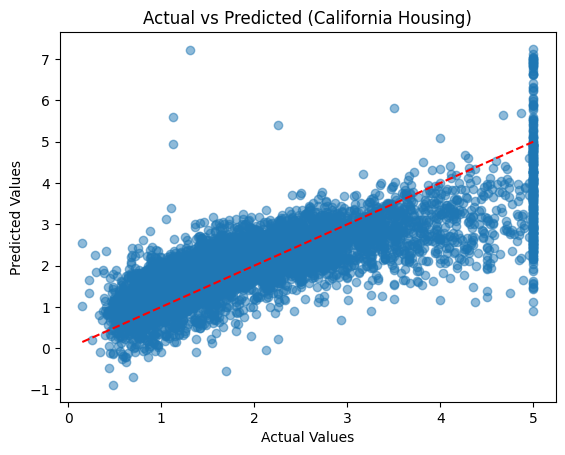

RMSE: 0.7278
MAE : 0.5352


In [17]:
y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE : {mse:.4f}')
print(f'R²  : {r2:.4f}')

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (California Housing)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()
# Evaluasi tambahan RMSE dan MAE
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f'RMSE: {rmse:.4f}')
print(f'MAE : {mae:.4f}')

In [16]:
import pickle
pickle.dump(lr_model, open('finalized_model.sav', 'wb'))
print('Model berhasil disimpan!')

Model berhasil disimpan!
